# NLM Cell Crop Splits

Create strict patient-level train/val/test CSV splits and optional K-fold CV CSVs from preprocessed NLM cell crops.

The split pipeline has four stages:

1. Load `metadata_with_batch_effect.csv` so every crop has a `background_label`.
2. Assign whole patients to train/val/test, avoiding patient leakage.
3. Downsample each split to the requested class and background proportions.
4. Assign the requested HR/LR resolution labels for SR training.
5. Optionally write patient-level `train_fold_i.csv` and `val_fold_i.csv` files for K-fold cross-validation without a held-out test set.


In [22]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter

REPO_ROOT = Path("/projects/compures/nicolas/signal_sr")
CROP_ROOT = Path("/projects/compures/datasets/NLM/crops")
METADATA_PATH = CROP_ROOT / "metadata_with_batch_effect.csv"
SEED = 2026
SPLIT_DIR = REPO_ROOT / f"data/nlm/splits/biased_colors/kfolds/seed_{SEED}"
WRITE_KFOLD_SPLITS = True
N_K_FOLDS = 5
KFOLD_SPLIT_ORDER = ["train", "val"]

SPLIT_ORDER = ["train", "val", "test"]
SPLIT_RATIOS = {"train": 0.95, "val": 0.025, "test": 0.025}
LABEL_TO_IDX = {"uninfected": 0, "parasitized": 1}
BACKGROUND_LABELS = ["red_background", "blue_background", "cropped_background"]
RESOLUTION_LABELS = ["HR", "LR"]
RESOLUTION_TO_DOMAIN = {"LR": 0, "HR": 1}

# Set TARGET_LABEL_PROPORTIONS to None to keep the natural class distribution.
# Set a split to None to keep its natural class distribution only for that split.
TARGET_LABEL_PROPORTIONS = {
    "train": {"uninfected": 0.5, "parasitized": 0.5},  # CHANGED !!!!!
    "val": {"uninfected": 0.5, "parasitized": 0.5},
    "test": {"uninfected": 0.5, "parasitized": 0.5},
}

# Set TARGET_BACKGROUND_PROPORTIONS to None to keep natural background distributions.
# Set a label to None to keep its natural background distribution.
TARGET_BACKGROUND_PROPORTIONS = {
    # "parasitized": None,
    # "uninfected": None,
    "parasitized": {"red_background": 1.0, "blue_background": 0.0, "cropped_background": 0.0},
    "uninfected": {"red_background": 0.0, "blue_background": 1.0, "cropped_background": 0.0},
}

# Resolution labels used by the SR model: domain 1 is HR, domain 0 is LR.
TARGET_RESOLUTION_PROPORTIONS = {
    "train": {"HR": 1.0, "LR": 0.0},
    "val": {"HR": 0.0, "LR": 1.0},
    "test": {"HR": 0.0, "LR": 1.0},
}

OUTPUT_COLUMNS = [
    "crop_path",
    "relative_path",
    "label",
    "label_name",
    "patient_id",
    "annotation_set",
    "image_name",
    "cell_id",
    "background_label",
    "resolution",
    "domain",
    "split",
]


In [23]:
def absolute_crop_path(path, crop_root):
    path = Path(path)
    return path if path.is_absolute() else crop_root / path


def load_crop_table(metadata_path, crop_root):
    metadata_path = Path(metadata_path)
    crop_root = Path(crop_root)
    if not metadata_path.is_file():
        raise FileNotFoundError(f"Missing metadata file: {metadata_path}")

    df = pd.read_csv(metadata_path)
    required = {
        "crop_path",
        "label_name",
        "patient_id",
        "annotation_set",
        "image_name",
        "cell_id",
        "background_label",
    }
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Missing required metadata columns: {sorted(missing)}")
    if df.empty:
        raise ValueError(f"No crops found in {metadata_path}")

    unknown_labels = sorted(set(df["label_name"]) - set(LABEL_TO_IDX))
    if unknown_labels:
        raise ValueError(f"Unknown label_name values: {unknown_labels}")
    unknown_backgrounds = sorted(set(df["background_label"]) - set(BACKGROUND_LABELS))
    if unknown_backgrounds:
        raise ValueError(f"Unknown background_label values: {unknown_backgrounds}")

    df = df.copy()
    df["crop_path"] = df["crop_path"].map(lambda path: absolute_crop_path(path, crop_root))
    df["relative_path"] = df["crop_path"].map(lambda path: str(path.relative_to(crop_root)))
    df["crop_path"] = df["crop_path"].map(str)
    df["label"] = df["label_name"].map(LABEL_TO_IDX).astype(int)
    return df.sort_values("relative_path").reset_index(drop=True)


df = load_crop_table(METADATA_PATH, CROP_ROOT)
print(f"Loaded {len(df):,} crops from {df.patient_id.nunique():,} patients")
display(df.groupby("label_name").size().rename("n"))
display(df.groupby(["label_name", "background_label"]).size().rename("n").unstack(fill_value=0))


Loaded 196,663 crops from 193 patients


label_name
parasitized      7952
uninfected     188711
Name: n, dtype: int64

background_label,blue_background,cropped_background,red_background
label_name,,,
parasitized,2340,607,5005
uninfected,84785,16214,87712


In [24]:
def validate_split_ratios(split_ratios):
    total = sum(split_ratios.values())
    if not np.isclose(total, 1.0):
        raise ValueError(f"SPLIT_RATIOS must sum to 1.0, got {total}")
    if list(split_ratios) != SPLIT_ORDER:
        raise ValueError(f"SPLIT_RATIOS keys must follow SPLIT_ORDER: {SPLIT_ORDER}")


def make_patient_counts(df):
    counts = df.pivot_table(index="patient_id", columns="label_name", values="crop_path", aggfunc="count", fill_value=0)
    for label_name in LABEL_TO_IDX:
        if label_name not in counts.columns:
            counts[label_name] = 0
    counts = counts[list(LABEL_TO_IDX)]
    counts["total"] = counts.sum(axis=1)
    return counts.reset_index()


def objective(counts_by_split, targets_by_split, columns):
    score = 0.0
    for split_name, target in targets_by_split.items():
        denom = target[columns].clip(lower=1.0)
        error = (counts_by_split[split_name][columns] - target[columns]) / denom
        score += float((error**2).sum())
    return score


def assign_patient_splits(df, split_ratios, seed):
    validate_split_ratios(split_ratios)
    split_names = list(split_ratios)
    columns = list(LABEL_TO_IDX) + ["total"]
    patients = make_patient_counts(df)

    rng = np.random.default_rng(seed)
    patients["_tie_break"] = rng.random(len(patients))
    patients = patients.sort_values(["parasitized", "total", "_tie_break"], ascending=[False, False, True])

    totals = patients[columns].sum().astype(float)
    targets = {split_name: totals * ratio for split_name, ratio in split_ratios.items()}
    counts = {split_name: pd.Series(0.0, index=columns) for split_name in split_names}
    split_patients = {split_name: [] for split_name in split_names}

    for _, patient in patients.iterrows():
        patient_counts = patient[columns].astype(float)
        best_split, best_score = None, None
        for split_name in split_names:
            trial_counts = {name: value.copy() for name, value in counts.items()}
            trial_counts[split_name] = trial_counts[split_name] + patient_counts
            score = objective(trial_counts, targets, columns)
            if best_score is None or score < best_score:
                best_split, best_score = split_name, score
        counts[best_split] = counts[best_split] + patient_counts
        split_patients[best_split].append(patient["patient_id"])

    patient_to_split = {patient_id: split_name for split_name, patient_ids in split_patients.items() for patient_id in patient_ids}
    out = df.copy()
    out["split"] = out["patient_id"].map(patient_to_split)
    return out


def assert_no_patient_leakage(df):
    leaks = df.groupby("patient_id")["split"].nunique()
    if leaks.max() != 1:
        raise AssertionError("At least one patient appears in multiple splits")


split_df = assign_patient_splits(df, SPLIT_RATIOS, SEED)
assert_no_patient_leakage(split_df)
display(split_df.groupby(["split", "label_name"]).size().unstack(fill_value=0).reindex(SPLIT_ORDER))
display(split_df.groupby(["split", "label_name", "background_label"]).size().unstack(fill_value=0).reindex(SPLIT_ORDER, level=0))


label_name,parasitized,uninfected
split,,
train,7058,178825
val,454,4852
test,440,5034


background_label   blue_background  cropped_background  red_background
split label_name                                                      
train parasitized             2139                 526            4393
      uninfected             77740               15446           85639
val   parasitized               99                  35             320
      uninfected              3906                 370             576
test  parasitized              102                  46             292
      uninfected              3139                 398            1497

In [25]:
def validate_props(props, names, context):
    props = {name: float(props.get(name, 0.0)) for name in names}
    if any(value < 0 for value in props.values()):
        raise ValueError(f"Negative proportion in {context}: {props}")
    total = sum(props.values())
    if not np.isclose(total, 1.0):
        raise ValueError(f"Proportions in {context} must sum to 1.0, got {total}")
    return props


def natural_props(counts, names):
    counts = dict(counts)
    total = sum(counts.get(name, 0) for name in names)
    if total == 0:
        return {name: 0.0 for name in names}
    return {name: counts.get(name, 0) / total for name in names}


def label_props_for_split(split_part, split_name):
    if TARGET_LABEL_PROPORTIONS is None:
        return natural_props(split_part["label_name"].value_counts(), list(LABEL_TO_IDX))
    props = TARGET_LABEL_PROPORTIONS.get(split_name)
    if props is None:
        return natural_props(split_part["label_name"].value_counts(), list(LABEL_TO_IDX))
    return validate_props(props, list(LABEL_TO_IDX), f"TARGET_LABEL_PROPORTIONS[{split_name!r}]")


def background_props_for_label(label_part, label_name):
    if TARGET_BACKGROUND_PROPORTIONS is None:
        return natural_props(label_part["background_label"].value_counts(), BACKGROUND_LABELS)
    props = TARGET_BACKGROUND_PROPORTIONS.get(label_name)
    if props is None:
        return natural_props(label_part["background_label"].value_counts(), BACKGROUND_LABELS)
    return validate_props(props, BACKGROUND_LABELS, f"TARGET_BACKGROUND_PROPORTIONS[{label_name!r}]")


def joint_target_props(split_part, split_name):
    label_props = label_props_for_split(split_part, split_name)
    joint_props = {}
    for label_name in LABEL_TO_IDX:
        label_part = split_part[split_part["label_name"] == label_name]
        background_props = background_props_for_label(label_part, label_name)
        for background_label in BACKGROUND_LABELS:
            joint_props[(label_name, background_label)] = label_props[label_name] * background_props[background_label]

    total = sum(joint_props.values())
    if not np.isclose(total, 1.0):
        raise ValueError(f"Joint target proportions for split {split_name} sum to {total}")
    return joint_props


def keep_counts_for_joint_props(available, joint_props, split_name):
    active = [key for key, proportion in joint_props.items() if proportion > 0]
    missing = [key for key in active if available.get(key, 0) == 0]
    if missing:
        raise ValueError(f"Split {split_name} cannot satisfy requested proportions; missing combinations: {missing}")
    if not active:
        return {key: 0 for key in joint_props}

    total_to_keep = int(np.floor(min(available.get(key, 0) / joint_props[key] for key in active)))
    counts = {key: int(np.floor(total_to_keep * proportion)) for key, proportion in joint_props.items()}

    while sum(counts.values()) < total_to_keep:
        candidates = sorted(
            active,
            key=lambda key: (total_to_keep * joint_props[key] - counts[key], available.get(key, 0) - counts[key]),
            reverse=True,
        )
        for key in candidates:
            if counts[key] < available.get(key, 0):
                counts[key] += 1
                break
        else:
            break
    return counts


def downsample_to_targets(df, seed):
    kept, unused = [], []
    for split_index, split_name in enumerate(SPLIT_ORDER):
        split_part = df[df["split"] == split_name]
        joint_props = joint_target_props(split_part, split_name)
        available = split_part.groupby(["label_name", "background_label"]).size().to_dict()
        keep_counts = keep_counts_for_joint_props(available, joint_props, split_name)

        kept_indices = []
        for label_name, label_index in LABEL_TO_IDX.items():
            for background_index, background_label in enumerate(BACKGROUND_LABELS):
                n_keep = keep_counts[(label_name, background_label)]
                group = split_part[(split_part["label_name"] == label_name) & (split_part["background_label"] == background_label)]
                if n_keep > 0:
                    random_state = seed + 1000 * split_index + 100 * label_index + background_index
                    kept_indices.extend(group.sample(n=n_keep, random_state=random_state).index.tolist())

        kept_split = split_part.loc[sorted(kept_indices)]
        kept.append(kept_split)
        unused.append(split_part.drop(index=kept_split.index))

    kept_df = pd.concat(kept, ignore_index=True) if kept else df.iloc[0:0].copy()
    unused_df = pd.concat(unused, ignore_index=True) if unused else df.iloc[0:0].copy()
    return kept_df, unused_df


def integer_counts_for_props(total, props, names):
    counts = {name: int(np.floor(total * props[name])) for name in names}
    while sum(counts.values()) < total:
        candidates = sorted(names, key=lambda name: total * props[name] - counts[name], reverse=True)
        counts[candidates[0]] += 1
    return counts


def resolution_props_for_split(split_name):
    if TARGET_RESOLUTION_PROPORTIONS is None or split_name not in TARGET_RESOLUTION_PROPORTIONS:
        raise ValueError(f"Missing resolution proportions for split {split_name}")
    return validate_props(TARGET_RESOLUTION_PROPORTIONS[split_name], RESOLUTION_LABELS, f"TARGET_RESOLUTION_PROPORTIONS[{split_name!r}]")


def assign_resolution_labels(df, seed):
    out = df.copy()
    out["resolution"] = pd.NA
    out["domain"] = pd.NA

    for split_index, split_name in enumerate(SPLIT_ORDER):
        indices = out.index[out["split"] == split_name].to_numpy()
        props = resolution_props_for_split(split_name)
        counts = integer_counts_for_props(len(indices), props, RESOLUTION_LABELS)
        rng = np.random.default_rng(seed + 10_000 + split_index)
        shuffled = rng.permutation(indices)

        start = 0
        for resolution in RESOLUTION_LABELS:
            stop = start + counts[resolution]
            resolution_indices = shuffled[start:stop]
            out.loc[resolution_indices, "resolution"] = resolution
            out.loc[resolution_indices, "domain"] = RESOLUTION_TO_DOMAIN[resolution]
            start = stop

    if out["resolution"].isna().any() or out["domain"].isna().any():
        raise AssertionError("Some rows were not assigned a resolution/domain")
    out["domain"] = out["domain"].astype(int)
    return out


def summarize(df, stage):
    rows = []
    for split_name in SPLIT_ORDER:
        part = df[df["split"] == split_name]
        label_counts = part["label_name"].value_counts().to_dict()
        resolution_counts = part["resolution"].value_counts().to_dict() if "resolution" in part else {}
        total = len(part)
        rows.append(
            {
                "stage": stage,
                "split": split_name,
                "n_crops": total,
                "n_patients": part["patient_id"].nunique(),
                "uninfected": label_counts.get("uninfected", 0),
                "parasitized": label_counts.get("parasitized", 0),
                "parasitized_fraction": label_counts.get("parasitized", 0) / total if total else 0.0,
                "HR": resolution_counts.get("HR", 0),
                "LR": resolution_counts.get("LR", 0),
                "HR_fraction": resolution_counts.get("HR", 0) / total if total else 0.0,
            }
        )
    return pd.DataFrame(rows)


def make_background_summary(df):
    index = pd.MultiIndex.from_product([SPLIT_ORDER, list(LABEL_TO_IDX), BACKGROUND_LABELS], names=["split", "label_name", "background_label"])
    counts = df.groupby(["split", "label_name", "background_label"]).size().reindex(index, fill_value=0).rename("n").reset_index()
    counts["total_for_split_label"] = counts.groupby(["split", "label_name"])["n"].transform("sum")
    counts["fraction_within_split_label"] = np.where(
        counts["total_for_split_label"] > 0,
        counts["n"] / counts["total_for_split_label"],
        0.0,
    )
    return counts


def make_resolution_summary(df):
    index = pd.MultiIndex.from_product([SPLIT_ORDER, RESOLUTION_LABELS], names=["split", "resolution"])
    counts = df.groupby(["split", "resolution"]).size().reindex(index, fill_value=0).rename("n").reset_index()
    counts["total_for_split"] = counts.groupby("split")["n"].transform("sum")
    counts["fraction_within_split"] = np.where(counts["total_for_split"] > 0, counts["n"] / counts["total_for_split"], 0.0)
    return counts


final_df, unused_df = downsample_to_targets(split_df, SEED)
final_df = assign_resolution_labels(final_df, SEED)
assert_no_patient_leakage(final_df)

unused_df = unused_df.copy()
unused_df["resolution"] = pd.NA
unused_df["domain"] = pd.NA

summary = pd.concat(
    [summarize(split_df, "before_balance"), summarize(final_df, "after_balance"), summarize(unused_df, "unused")],
    ignore_index=True,
)
background_summary = make_background_summary(final_df)
resolution_summary = make_resolution_summary(final_df)

display(summary)
display(background_summary)
display(resolution_summary)


,stage,split,n_crops,n_patients,uninfected,parasitized,parasitized_fraction,HR,LR,HR_fraction
0,before_balance,train,185883,184,178825,7058,0.037970,0,0,0.0
1,before_balance,val,5306,4,4852,454,0.085564,0,0,0.0
2,before_balance,test,5474,5,5034,440,0.080380,0,0,0.0
3,after_balance,train,8786,176,4393,4393,0.500000,8786,0,1.0
4,after_balance,val,640,4,320,320,0.500000,0,640,0.0
5,after_balance,test,584,5,292,292,0.500000,0,584,0.0
6,unused,train,177097,184,174432,2665,0.015048,0,0,0.0
7,unused,val,4666,4,4532,134,0.028718,0,0,0.0
8,unused,test,4890,5,4742,148,0.030266,0,0,0.0


,split,label_name,background_label,n,total_for_split_label,fraction_within_split_label
0,train,uninfected,red_background,0,4393,0.0
1,train,uninfected,blue_background,4393,4393,1.0
2,train,uninfected,cropped_background,0,4393,0.0
3,train,parasitized,red_background,4393,4393,1.0
4,train,parasitized,blue_background,0,4393,0.0
5,train,parasitized,cropped_background,0,4393,0.0
6,val,uninfected,red_background,0,320,0.0
7,val,uninfected,blue_background,320,320,1.0
8,val,uninfected,cropped_background,0,320,0.0
9,val,parasitized,red_background,320,320,1.0


,split,resolution,n,total_for_split,fraction_within_split
0,train,HR,8786,8786,1.0
1,train,LR,0,8786,0.0
2,val,HR,0,640,0.0
3,val,LR,640,640,1.0
4,test,HR,0,584,0.0
5,test,LR,584,584,1.0


In [26]:
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

for split_name in SPLIT_ORDER:
    split_part = final_df[final_df["split"] == split_name].sort_values(["patient_id", "label_name", "background_label", "relative_path"])
    split_part[OUTPUT_COLUMNS].to_csv(SPLIT_DIR / f"{split_name}.csv", index=False)

unused_part = unused_df.sort_values(["split", "patient_id", "label_name", "background_label", "relative_path"]) if not unused_df.empty else unused_df
unused_part[OUTPUT_COLUMNS].to_csv(SPLIT_DIR / "unused.csv", index=False)
summary.to_csv(SPLIT_DIR / "summary.csv", index=False)
background_summary.to_csv(SPLIT_DIR / "background_summary.csv", index=False)
resolution_summary.to_csv(SPLIT_DIR / "resolution_summary.csv", index=False)

print(f"Wrote split CSVs to {SPLIT_DIR}")
display(summary[summary["stage"] == "after_balance"].reset_index(drop=True))


Wrote split CSVs to /projects/compures/nicolas/signal_sr/data/nlm/splits/biased_colors/kfolds/seed_2026


,stage,split,n_crops,n_patients,uninfected,parasitized,parasitized_fraction,HR,LR,HR_fraction
0,after_balance,train,8786,176,4393,4393,0.5,8786,0,1.0
1,after_balance,val,640,4,320,320,0.5,0,640,0.0
2,after_balance,test,584,5,292,292,0.5,0,584,0.0


In [27]:
def assign_patient_folds(df, n_folds, seed):
    n_folds = int(n_folds)
    if n_folds < 2:
        raise ValueError("N_K_FOLDS must be >= 2")

    columns = list(LABEL_TO_IDX) + ["total"]
    patients = make_patient_counts(df)
    if len(patients) < n_folds:
        raise ValueError(f"Cannot create {n_folds} folds from only {len(patients)} patients")

    rng = np.random.default_rng(seed)
    patients["_tie_break"] = rng.random(len(patients))
    patients = patients.sort_values(["parasitized", "total", "_tie_break"], ascending=[False, False, True])

    totals = patients[columns].sum().astype(float)
    targets = {fold: totals / n_folds for fold in range(1, n_folds + 1)}
    counts = {fold: pd.Series(0.0, index=columns) for fold in targets}
    fold_patients = {fold: [] for fold in targets}

    for _, patient in patients.iterrows():
        patient_counts = patient[columns].astype(float)
        best_fold, best_score = None, None
        for fold in targets:
            trial_counts = {name: value.copy() for name, value in counts.items()}
            trial_counts[fold] = trial_counts[fold] + patient_counts
            score = objective(trial_counts, targets, columns)
            if best_score is None or score < best_score:
                best_fold, best_score = fold, score
        counts[best_fold] = counts[best_fold] + patient_counts
        fold_patients[best_fold].append(patient["patient_id"])

    patient_to_fold = {patient_id: fold for fold, patient_ids in fold_patients.items() for patient_id in patient_ids}
    out = df.copy()
    out["fold"] = out["patient_id"].map(patient_to_fold).astype(int)
    return out


def assert_no_fold_leakage(train_df, val_df, fold):
    overlap = set(train_df["patient_id"]).intersection(set(val_df["patient_id"]))
    if overlap:
        raise AssertionError(f"Fold {fold} has patient leakage between train and val: {sorted(overlap)[:5]}")


def downsample_to_targets_for_splits(df, split_order, seed):
    kept, unused = [], []
    for split_index, split_name in enumerate(split_order):
        split_part = df[df["split"] == split_name]
        if split_part.empty:
            raise ValueError(f"No rows found for split {split_name!r}")
        joint_props = joint_target_props(split_part, split_name)
        available = split_part.groupby(["label_name", "background_label"]).size().to_dict()
        keep_counts = keep_counts_for_joint_props(available, joint_props, split_name)

        kept_indices = []
        for label_name, label_index in LABEL_TO_IDX.items():
            for background_index, background_label in enumerate(BACKGROUND_LABELS):
                n_keep = keep_counts[(label_name, background_label)]
                group = split_part[(split_part["label_name"] == label_name) & (split_part["background_label"] == background_label)]
                if n_keep > 0:
                    random_state = seed + 1000 * split_index + 100 * label_index + background_index
                    kept_indices.extend(group.sample(n=n_keep, random_state=random_state).index.tolist())

        kept_split = split_part.loc[sorted(kept_indices)]
        kept.append(kept_split)
        unused.append(split_part.drop(index=kept_split.index))

    kept_df = pd.concat(kept, ignore_index=True) if kept else df.iloc[0:0].copy()
    unused_df = pd.concat(unused, ignore_index=True) if unused else df.iloc[0:0].copy()
    return kept_df, unused_df


def assign_resolution_labels_for_splits(df, split_order, seed):
    out = df.copy()
    out["resolution"] = pd.NA
    out["domain"] = pd.NA

    for split_index, split_name in enumerate(split_order):
        indices = out.index[out["split"] == split_name].to_numpy()
        props = resolution_props_for_split(split_name)
        counts = integer_counts_for_props(len(indices), props, RESOLUTION_LABELS)
        rng = np.random.default_rng(seed + 10_000 + split_index)
        shuffled = rng.permutation(indices)

        start = 0
        for resolution in RESOLUTION_LABELS:
            stop = start + counts[resolution]
            resolution_indices = shuffled[start:stop]
            out.loc[resolution_indices, "resolution"] = resolution
            out.loc[resolution_indices, "domain"] = RESOLUTION_TO_DOMAIN[resolution]
            start = stop

    if out["resolution"].isna().any() or out["domain"].isna().any():
        raise AssertionError("Some rows were not assigned a resolution/domain")
    out["domain"] = out["domain"].astype(int)
    return out


def summarize_for_splits(df, stage, split_order):
    rows = []
    for split_name in split_order:
        part = df[df["split"] == split_name]
        label_counts = part["label_name"].value_counts().to_dict()
        resolution_counts = part["resolution"].value_counts().to_dict() if "resolution" in part else {}
        total = len(part)
        rows.append(
            {
                "stage": stage,
                "split": split_name,
                "n_crops": total,
                "n_patients": part["patient_id"].nunique(),
                "uninfected": label_counts.get("uninfected", 0),
                "parasitized": label_counts.get("parasitized", 0),
                "parasitized_fraction": label_counts.get("parasitized", 0) / total if total else 0.0,
                "HR": resolution_counts.get("HR", 0),
                "LR": resolution_counts.get("LR", 0),
                "HR_fraction": resolution_counts.get("HR", 0) / total if total else 0.0,
            }
        )
    return pd.DataFrame(rows)


def make_background_summary_for_splits(df, split_order):
    index = pd.MultiIndex.from_product([split_order, list(LABEL_TO_IDX), BACKGROUND_LABELS], names=["split", "label_name", "background_label"])
    counts = df.groupby(["split", "label_name", "background_label"]).size().reindex(index, fill_value=0).rename("n").reset_index()
    counts["total_for_split_label"] = counts.groupby(["split", "label_name"])["n"].transform("sum")
    counts["fraction_within_split_label"] = np.where(
        counts["total_for_split_label"] > 0,
        counts["n"] / counts["total_for_split_label"],
        0.0,
    )
    return counts


def make_resolution_summary_for_splits(df, split_order):
    index = pd.MultiIndex.from_product([split_order, RESOLUTION_LABELS], names=["split", "resolution"])
    counts = df.groupby(["split", "resolution"]).size().reindex(index, fill_value=0).rename("n").reset_index()
    counts["total_for_split"] = counts.groupby("split")["n"].transform("sum")
    counts["fraction_within_split"] = np.where(counts["total_for_split"] > 0, counts["n"] / counts["total_for_split"], 0.0)
    return counts


def write_kfold_splits(df, split_dir, n_folds, seed):
    split_dir = Path(split_dir)
    split_dir.mkdir(parents=True, exist_ok=True)
    folded_df = assign_patient_folds(df, n_folds, seed)

    patient_folds = folded_df[["patient_id", "fold"]].drop_duplicates().sort_values(["fold", "patient_id"])
    patient_folds.to_csv(split_dir / "kfold_patient_assignments.csv", index=False)

    summaries, background_summaries, resolution_summaries = [], [], []
    unused_parts = []
    fold_output_columns = OUTPUT_COLUMNS + ["fold"]
    for fold in range(1, int(n_folds) + 1):
        fold_split = folded_df.copy()
        fold_split["split"] = np.where(fold_split["fold"] == fold, "val", "train")
        assert_no_patient_leakage(fold_split)

        fold_seed = seed + 100_000 * fold
        fold_final_df, fold_unused_df = downsample_to_targets_for_splits(fold_split, KFOLD_SPLIT_ORDER, fold_seed)
        fold_final_df = assign_resolution_labels_for_splits(fold_final_df, KFOLD_SPLIT_ORDER, fold_seed)
        fold_final_df["fold"] = fold

        fold_unused_df = fold_unused_df.copy()
        fold_unused_df["resolution"] = pd.NA
        fold_unused_df["domain"] = pd.NA
        fold_unused_df["fold"] = fold
        unused_parts.append(fold_unused_df)

        train_part = fold_final_df[fold_final_df["split"] == "train"]
        val_part = fold_final_df[fold_final_df["split"] == "val"]
        assert_no_fold_leakage(train_part, val_part, fold)

        for split_name in KFOLD_SPLIT_ORDER:
            split_part = fold_final_df[fold_final_df["split"] == split_name].sort_values(
                ["patient_id", "label_name", "background_label", "relative_path"]
            )
            columns = [column for column in fold_output_columns if column in split_part.columns]
            split_part[columns].to_csv(split_dir / f"{split_name}_fold_{fold}.csv", index=False)

        fold_summary = pd.concat(
            [
                summarize_for_splits(fold_split, "before_balance", KFOLD_SPLIT_ORDER),
                summarize_for_splits(fold_final_df, "after_balance", KFOLD_SPLIT_ORDER),
                summarize_for_splits(fold_unused_df, "unused", KFOLD_SPLIT_ORDER),
            ],
            ignore_index=True,
        )
        fold_summary.insert(0, "fold", fold)
        summaries.append(fold_summary)

        fold_background_summary = make_background_summary_for_splits(fold_final_df, KFOLD_SPLIT_ORDER)
        fold_background_summary.insert(0, "fold", fold)
        background_summaries.append(fold_background_summary)

        fold_resolution_summary = make_resolution_summary_for_splits(fold_final_df, KFOLD_SPLIT_ORDER)
        fold_resolution_summary.insert(0, "fold", fold)
        resolution_summaries.append(fold_resolution_summary)

    kfold_summary = pd.concat(summaries, ignore_index=True)
    kfold_background_summary = pd.concat(background_summaries, ignore_index=True)
    kfold_resolution_summary = pd.concat(resolution_summaries, ignore_index=True)
    kfold_unused = pd.concat(unused_parts, ignore_index=True) if unused_parts else df.iloc[0:0].copy()

    kfold_summary.to_csv(split_dir / "kfold_summary.csv", index=False)
    kfold_background_summary.to_csv(split_dir / "kfold_background_summary.csv", index=False)
    kfold_resolution_summary.to_csv(split_dir / "kfold_resolution_summary.csv", index=False)
    kfold_unused[[column for column in fold_output_columns if column in kfold_unused.columns]].to_csv(split_dir / "unused_kfold.csv", index=False)
    return folded_df, kfold_summary


if WRITE_KFOLD_SPLITS:
    folded_df, kfold_summary = write_kfold_splits(df, SPLIT_DIR, N_K_FOLDS, SEED)
    print(f"Wrote {N_K_FOLDS}-fold CSVs to {SPLIT_DIR}")
    display(kfold_summary[kfold_summary["stage"] == "after_balance"].reset_index(drop=True))


Wrote 5-fold CSVs to /projects/compures/nicolas/signal_sr/data/nlm/splits/biased_colors/kfolds/seed_2026


,fold,stage,split,n_crops,n_patients,uninfected,parasitized,parasitized_fraction,HR,LR,HR_fraction
0,1,after_balance,train,7926,146,3963,3963,0.5,7926,0,1.0
1,1,after_balance,val,2084,39,1042,1042,0.5,0,2084,0.0
2,2,after_balance,train,7710,148,3855,3855,0.5,7710,0,1.0
3,2,after_balance,val,2300,36,1150,1150,0.5,0,2300,0.0
4,3,after_balance,train,7924,149,3962,3962,0.5,7924,0,1.0
5,3,after_balance,val,2086,36,1043,1043,0.5,0,2086,0.0
6,4,after_balance,train,8822,147,4411,4411,0.5,8822,0,1.0
7,4,after_balance,val,1188,37,594,594,0.5,0,1188,0.0
8,5,after_balance,train,7658,148,3829,3829,0.5,7658,0,1.0
9,5,after_balance,val,2352,38,1176,1176,0.5,0,2352,0.0


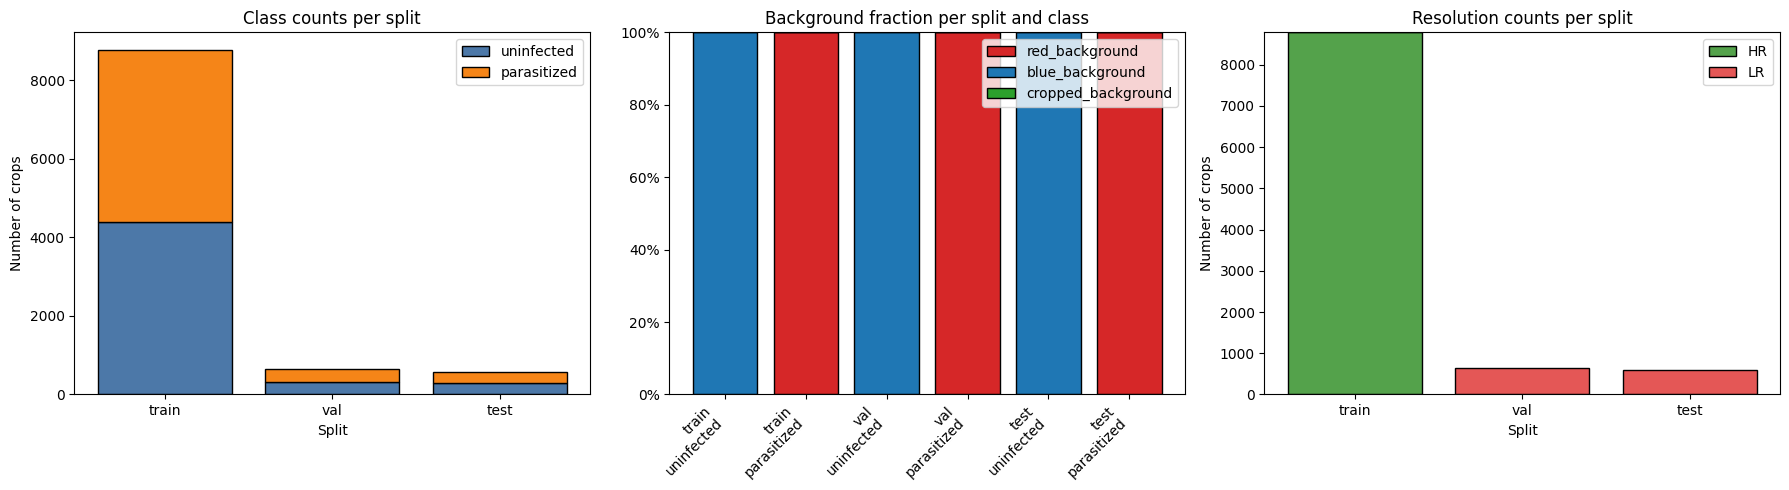

In [28]:
class_counts = final_df.groupby(["split", "label_name"]).size().unstack(fill_value=0).reindex(SPLIT_ORDER, fill_value=0)
resolution_counts = final_df.groupby(["split", "resolution"]).size().unstack(fill_value=0).reindex(SPLIT_ORDER, fill_value=0)
background_fractions = background_summary.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

label_colors = {"uninfected": "#4c78a8", "parasitized": "#f58518"}
bottom = np.zeros(len(SPLIT_ORDER))
for label_name in LABEL_TO_IDX:
    values = class_counts[label_name].to_numpy() if label_name in class_counts else np.zeros(len(SPLIT_ORDER))
    axes[0].bar(SPLIT_ORDER, values, bottom=bottom, label=label_name, color=label_colors[label_name], edgecolor="black")
    bottom += values
axes[0].set_title("Class counts per split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Number of crops")
axes[0].legend()

background_colors = {
    "red_background": "#d62728",
    "blue_background": "#1f77b4",
    "cropped_background": "#2ca02c",
}
x_labels = [f"{split_name}\n{label_name}" for split_name in SPLIT_ORDER for label_name in LABEL_TO_IDX]
x = np.arange(len(x_labels))
bottom = np.zeros(len(x_labels))
for background_label in BACKGROUND_LABELS:
    values = []
    for split_name in SPLIT_ORDER:
        for label_name in LABEL_TO_IDX:
            row = background_fractions[
                (background_fractions["split"] == split_name)
                & (background_fractions["label_name"] == label_name)
                & (background_fractions["background_label"] == background_label)
            ]
            values.append(float(row["fraction_within_split_label"].iloc[0]))
    values = np.asarray(values)
    axes[1].bar(x, values, bottom=bottom, label=background_label, color=background_colors[background_label], edgecolor="black")
    bottom += values
axes[1].set_title("Background fraction per split and class")
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels, rotation=45, ha="right")
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend()

resolution_colors = {"HR": "#54a24b", "LR": "#e45756"}
bottom = np.zeros(len(SPLIT_ORDER))
for resolution in RESOLUTION_LABELS:
    values = resolution_counts[resolution].to_numpy() if resolution in resolution_counts else np.zeros(len(SPLIT_ORDER))
    axes[2].bar(SPLIT_ORDER, values, bottom=bottom, label=resolution, color=resolution_colors[resolution], edgecolor="black")
    bottom += values
axes[2].set_title("Resolution counts per split")
axes[2].set_xlabel("Split")
axes[2].set_ylabel("Number of crops")
axes[2].legend()

plt.tight_layout()
plt.show()
